# First Analysis of our Dataset #
## Source: Gdelt Event Database ##
### tagesschau_zdf_pbs_events.csv ###

In [211]:
import pandas as pd
from matplotlib import pyplot as plt
from urllib.parse import urlparse
import seaborn as sns
from wordcloud import WordCloud

In [212]:
df = pd.read_csv("Data/tagesschau_zdf_pbs_events.csv")
print(list(df.columns),
df.shape)

['SQLDATE', 'SOURCEURL', 'AvgTone', 'NumArticles', 'Actor1Name', 'Actor2Name', 'EventCode'] (56981, 7)


### What Time window the dataset covers: ###

In [213]:
#Zeitraum des Datensatz
df['Datum_Zeit'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
df['Datum']= df['Datum_Zeit'].dt.date
print('Anfangsdatum:',df['Datum'].min() , '\nEnddatum:',df['Datum'].max())





Anfangsdatum: 2023-10-08 
Enddatum: 2025-10-10


### Extracting Topic of the Event/Article from the Url ###

In [214]:
#Thema aus der URL extrahieren

df['Thema'] = df['SOURCEURL'].apply(lambda x: x.rstrip('/').split('/')[-1].split('.')[0])

print(df[['SOURCEURL', 'Thema']])



                                               SOURCEURL  \
0      https://www.kpbs.org/podcasts/kpbs-midday-edit...   
1      https://www.tagesschau.de/inland/debatte-hilfe...   
2      https://www.tagesschau.de/ausland/asien/gaza-i...   
3      https://nhpbs.org/schedule/summary.aspx?progId...   
4      https://www.pbs.org/newshour/nation/5-things-t...   
...                                                  ...   
56976  https://www.cascadepbs.org/inside-cascade-pbs/...   
56977  https://www.cascadepbs.org/inside-cascade-pbs/...   
56978  https://www.cascadepbs.org/inside-cascade-pbs/...   
56979  https://www.cascadepbs.org/inside-cascade-pbs/...   
56980  https://www.cascadepbs.org/inside-cascade-pbs/...   

                                                   Thema  
0                    examining-americans-voting-behavior  
1                      debatte-hilfen-palaestinenser-100  
2                                gaza-israel-angriff-110  
3                                          

In [215]:

# Funktion, um Redaktion aus URL zu extrahieren
def get_redaktion(url):
    domain = urlparse(url).netloc  # extrahiert z.B. 'www.tagesschau.de'
    parts = domain.split('.')      # ['www', 'tagesschau', 'de']
    # Redaktion ist meist der mittlere Teil, außer spezielle Domains wie nhpbs
    if parts[0] == 'www':
        return parts[1]
    else:
        return parts[0]

# Neue Spalte erstellen
df['Redaktion'] = df['SOURCEURL'].apply(get_redaktion)

df_tagesschau = df[df['Redaktion'].str.lower() == 'tagesschau'].copy()

### Amount of Articles from each News Outlet ###

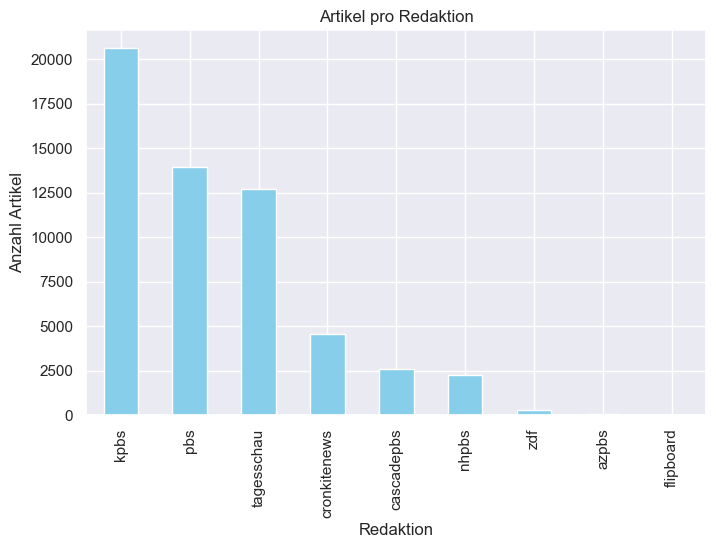

In [216]:
df['Redaktion'].value_counts().plot(
    kind='bar', 
    color='skyblue', 
    figsize=(8,5), 
    title='Artikel pro Redaktion'
)
plt.ylabel('Anzahl Artikel')
plt.xlabel('Redaktion')
plt.show()

### Articles related to the middle east ###

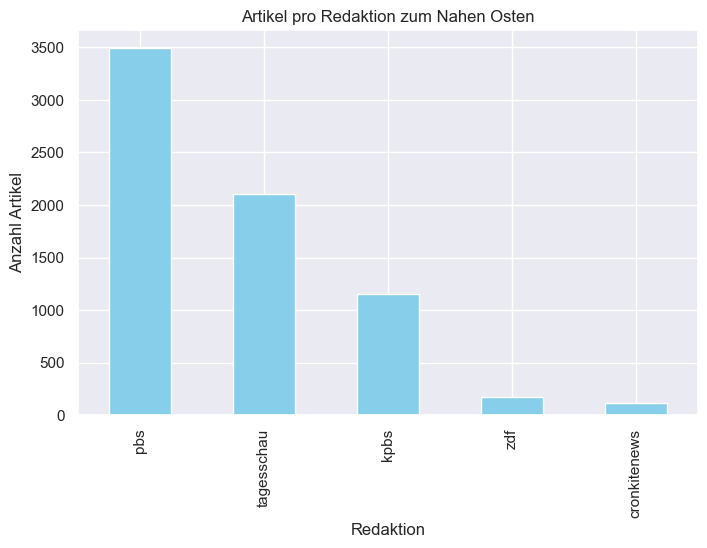

In [217]:
keywords = ["gaza", "palestina", "israel", "hamas", "krieg", "angriffe"]

# Maske auf die 'Thema'-Spalte anwenden, NaN ausschließen
mask = df['Thema'].fillna('').str.contains('|'.join(keywords), case=False)

df_filtered_1 = df[mask].copy()

df_filtered_1['Redaktion'].value_counts().plot(
    kind='bar', 
    color='skyblue', 
    figsize=(8,5), 
    title='Artikel pro Redaktion zum Nahen Osten'
)
plt.ylabel('Anzahl Artikel')
plt.xlabel('Redaktion')
plt.show()

### How much Articles in comparison to overall Articles ###

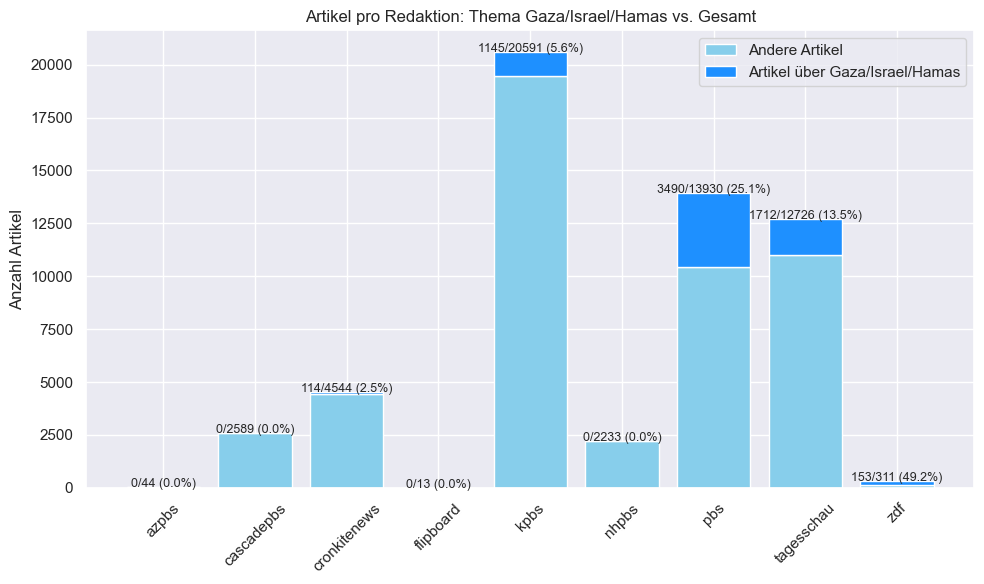

In [218]:


# Beispiel: df bereits gefiltert nach Redaktionen + Thema
keywords = ["gaza", "palestina", "israel", "hamas"]
mask = df['Thema'].fillna('').str.contains('|'.join(keywords), case=False)

# Aggregieren pro Redaktion
df_chart = df.groupby('Redaktion').agg(
    total=('Thema', 'count'),
    relevant=('Thema', lambda x: mask[x.index].sum())
).reset_index()

# Nicht-relevante Artikel
df_chart['other'] = df_chart['total'] - df_chart['relevant']

# Balken plotten (gestapelt)
plt.figure(figsize=(10,6))

plt.bar(df_chart['Redaktion'], df_chart['other'], color='skyblue', label='Andere Artikel')
plt.bar(df_chart['Redaktion'], df_chart['relevant'], bottom=df_chart['other'], color='dodgerblue', label='Artikel über Gaza/Israel/Hamas')

plt.ylabel('Anzahl Artikel')
plt.title('Artikel pro Redaktion: Thema Gaza/Israel/Hamas vs. Gesamt')
plt.xticks(rotation=45)
plt.legend()

# Prozentangaben über dem Balken
for i, row in df_chart.iterrows():
    total = row['total']
    relevant = row['relevant']
    pct = relevant / total * 100 if total > 0 else 0
    plt.text(i, total + 0.5, f'{relevant}/{total} ({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

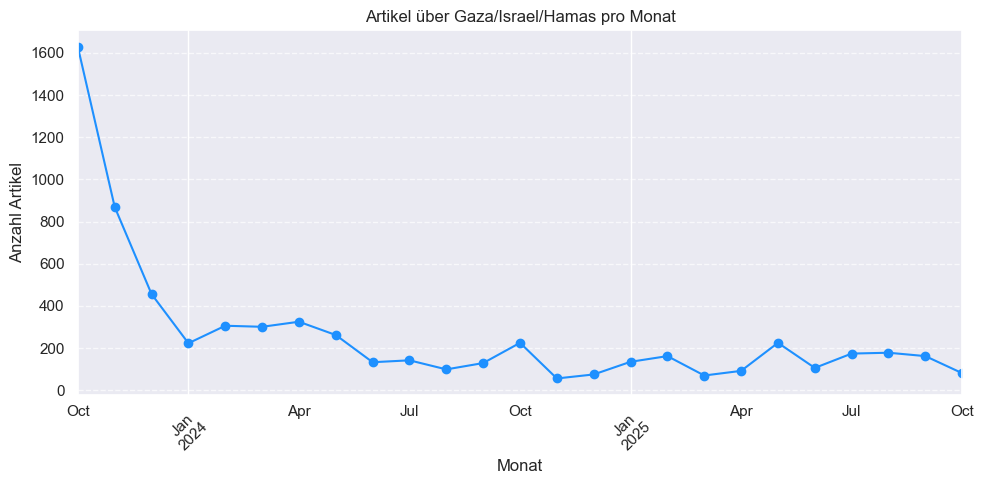

In [219]:


# Keywords definieren
keywords = ["gaza", "palestina", "israel", "hamas"]

# Maske für relevante Artikel
mask = df['Thema'].fillna('').str.contains('|'.join(keywords), case=False)
df_filtered = df[mask].copy()

# Gruppieren nach Monat
articles_per_month = df_filtered.groupby(df_filtered['Datum_Zeit'].dt.to_period('M')).size()

# Plot
plt.figure(figsize=(10,5))
articles_per_month.plot(kind='line', marker='o', color='dodgerblue')
plt.title('Artikel über Gaza/Israel/Hamas pro Monat')
plt.xlabel('Monat')
plt.ylabel('Anzahl Artikel')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### average Tone of each news outlet to the middle east ###

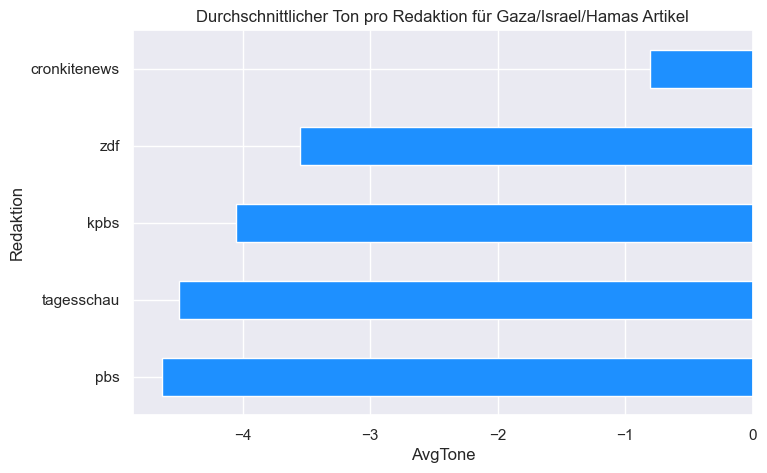

In [220]:
df_filtered.groupby('Redaktion')['AvgTone'].mean().sort_values().plot(
    kind='barh', color='dodgerblue', figsize=(8,5),
    title='Durchschnittlicher Ton pro Redaktion für Gaza/Israel/Hamas Artikel'
)
plt.xlabel('AvgTone')
plt.show()

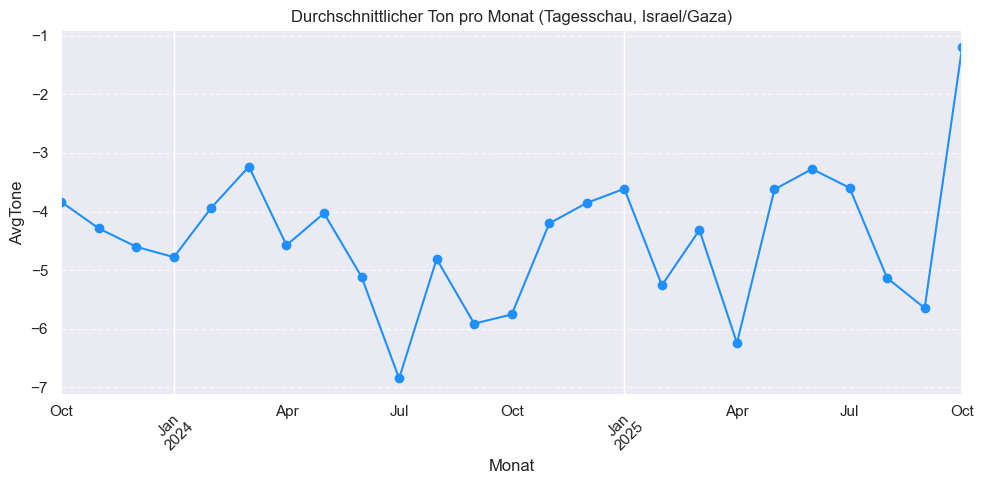

In [221]:
# Durchschnittlicher AvgTone pro Monat
mask_tagesschau = df['Redaktion'].str.lower() == 'tagesschau'

# Maske: nur Artikel zum Thema
mask_thema = df['Thema'].fillna('').str.contains('|'.join(keywords), case=False)

# Kombinierte Maske
mask = mask_tagesschau & mask_thema

# Gefiltertes DataFrame
df_filtered = df[mask].copy()

# Datum_Zeit als datetime sicherstellen
df_filtered['Datum_Zeit'] = pd.to_datetime(df_filtered['SQLDATE'], format='%Y%m%d')

# Durchschnittlicher AvgTone pro Monat
avg_tone_month = df_filtered.groupby(df_filtered['Datum_Zeit'].dt.to_period('M'))['AvgTone'].mean()

# Plot
plt.figure(figsize=(10,5))
avg_tone_month.plot(kind='line', marker='o', color='dodgerblue')
plt.title('Durchschnittlicher Ton pro Monat (Tagesschau, Israel/Gaza)')
plt.xlabel('Monat')
plt.ylabel('AvgTone')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Word Cloud of most common words in Article Title on the whole Dataset ###

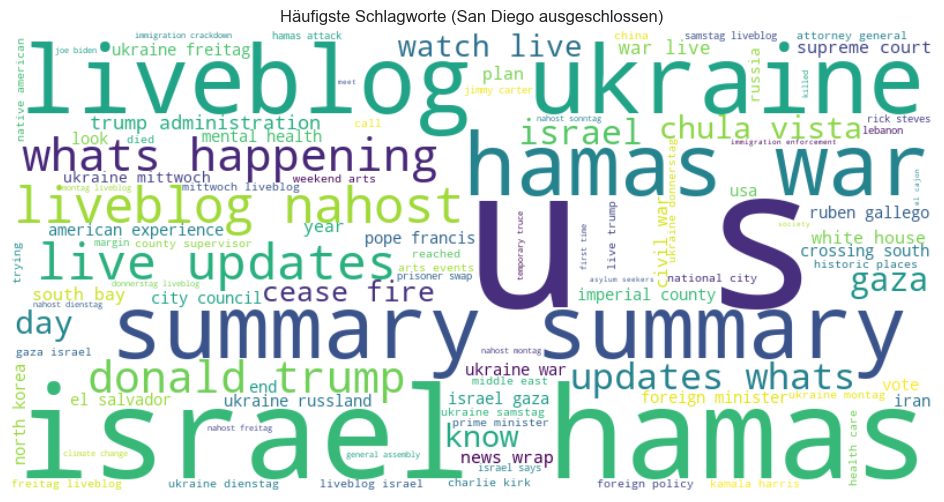

In [222]:
# Eigene Stopwords erweitern
custom_stopwords = set(WordCloud().stopwords)  # Standard-Stopwords
custom_stopwords.update(["san", "diego"])       # eigene Wörter, die ausgeschlossen werden sollen

# Wordcloud generieren
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    stopwords=custom_stopwords
).generate(text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Häufigste Schlagworte (San Diego ausgeschlossen)')
plt.show()